# La prueba de Wilcoxon para muestras pareadas (parte 2)

En este ejemplo práctico aplicaremos la prueba de los rangos con signo de Wilcoxon al caso en el cual tenemos muestras pareadas:

> Supongamos que somos Científicos de Datos y que queremos determinar si una mejora a una API existente genera **tiempos de respuestas menores**.

Veamos entonces cómo implementar todos los pasos para llevar a cabo esta prueba.

## 1. Desarrollo de la prueba de hipótesis

Es una prueba **unilateral** (pues queremos determinar si el tiempo de inferencia tras los cambios es menor).

### 1.1. Paso 1: definir el problema del negocio

> **Queremos hacer modificaciones a la API existente para que tenga mejores tiempos de respuesta**

### 1.2. Paso 2: redactar el problema del negocio como un problema de Ciencia de Datos/Machine Learning

> **¿Las modificaciones a la API generan tiempos de respuesta menores, desde el punto de vista estadístico, comparados con la API antes de introducir los cambios?**

### 1.3. Paso 3: definir $H_0$ y $H_1$

\begin{aligned}
H_0: \text{diferencias} &= 0 \\
H_1: \text{diferencias} &< 0 
\end{aligned}

### 1.4. Paso 4: definir $\alpha$

Asumiremos un nivel de significancia $\alpha = 0.05$ y recordemos que la prueba es **unilateral**.

### 1.5. Definir la potencia de la prueba ($1-\beta$) y el tamaño de la muestra ($n$)

Acá usamos la misma lógica de la prueba Wilcoxon de una muestra:

1. Definimos el tamaño del efecto deseado (RBC)
2. Definimos la potencia de la prueba deseada
3. Usamos Scipy y el módulo "TTestPower" para estimar $n_{\text{ttest}}$
4. Aplicamos la corrección para estimar el número de muestras: $n_{\text{Wilcoxon}} = \frac{n_{\text{ttest}}}{0.955}$

Veamos cómo diseñar la prueba teniendo en cuenta lo anterior.

### 1.5.1. Definir el tamaño del efecto deseado


De nuevo usamos la **correlación biserial de rango** (*rank-biserial correlation* o *RBC*) que mide la diferencia entre la proporción de rangos positivos ($W^+$) y la proporción de rangos negativos ($W^-$):

$$\text{RBC} = \frac{W^+-W^-}{W^++W^-}$$

Recordemos que los rangos más usuales son:

- $\text{RBC} \geq 0.1$: efecto "pequeño"
- $\text{RBC} \geq 0.3$: efecto "mediano"
- $\text{RBC} \geq > 0.5$: efecto "grande"

Así que buscaremos obtener un tamaño del efecto "grande": $\rightarrow RBC = 0.4$ (tras aplicar la prueba veremos si existe o no un efecto)

**Nota importante:**

Como usaremos más adelante el código Python para la prueba t, la equivalencia entre el $RBC$ de la prueba Wilcoxon y el $d$ de la prueba t es:

$$d = \frac{2\text{RBC}}{\sqrt{1-\text{RBC}^2}}$$

### 1.5.2. Definir la potencia de la prueba

Al igual que en ejemplos anteriores, asumiremos una potencia de 0.9

### 1.5.3. Estimación del tamaño de la muestra con Scipy

Seguiremos los mismos pasos que vimos en la lección 2:

In [1]:
import math
from statsmodels.stats.power import TTestPower

rbc = 0.4 # Tamaño del efecto esperado (definido por nosotros)
potencia = 0.9 # Potencia de la prueba esperada (definida por nosotros)
alpha = 0.05 # Nivel de significancia (definido por nosotros)

# 1. Estimar n-ttest
d_cohen = (2 * rbc) / math.sqrt(1 - rbc**2) # Aproximación al d de Cohen
analisis = TTestPower()
nttest = analisis.solve_power(
    effect_size = d_cohen,
    power = potencia,
    alpha = alpha,
    alternative = 'smaller', # "larger", "two-sided" Porque es una prueba unilateral (y menor que)
)

# 2. Estimar n-wilcoxon
n = math.ceil(nttest[0] / 0.955)

print(f"Efecto Cohen's d equivalente: {d_cohen:.2f}")
print(f"Tamaño de la muestra T-test: {math.ceil(nttest[0])}")
print(f"Tamaño de la muestra Wilcoxon: {n}")

Efecto Cohen's d equivalente: 0.87
Tamaño de la muestra T-test: 10
Tamaño de la muestra Wilcoxon: 11


/Users/miguel/.pyenv/versions/3.11.2/envs/academy/lib/python3.11/site-packages/statsmodels/stats/power.py:524: ConvergenceWarning: 
Failed to converge on a solution.

  warnings.warn(convergence_doc, ConvergenceWarning)


Es decir que necesitamos al menos 11 datos para poder estimar el tamaño del efecto esperado (si es que existe) y la potencia.

### 1.6. Paso 6: recolectar y preparar los datos

Supondremos que hemos recolectado $n=380$ datos correspondientes a los tiempos de respuesta de la API antes y después de los cambios:

In [2]:
import pandas as pd

RUTA = '/Users/miguel/Library/CloudStorage/GoogleDrive-miguel@codificandobits.com/My Drive/02-CODIFICANDOBITS.COM/04-Academia/01-Cursos/46-2026-04-EstadisticaInferencialNoParametrica/data/'

datos = pd.read_csv(RUTA + 'dataset_wilcoxon_pareados.csv')
datos

,antes,desp
0,18.0,13.8
1,27.2,27.1
2,23.7,23.1
3,21.6,22.7
4,14.5,14.6
...,...,...
375,17.1,17.7
376,25.5,24.9
377,12.4,11.1
378,25.0,26.3


En este caso hay un elemento importante a tener en cuenta:

> Como la prueba se aplica **sobre las diferencias**, no verificamos la normalidad de los datos sobre cada muestra individualmente sino **sobre sus diferencias**

Veamos cómo está distribuida cada variable pero, sobre todo, veamos cómo está distribuida la diferencia. En cada caso calcularemos también las medianas de los datos:

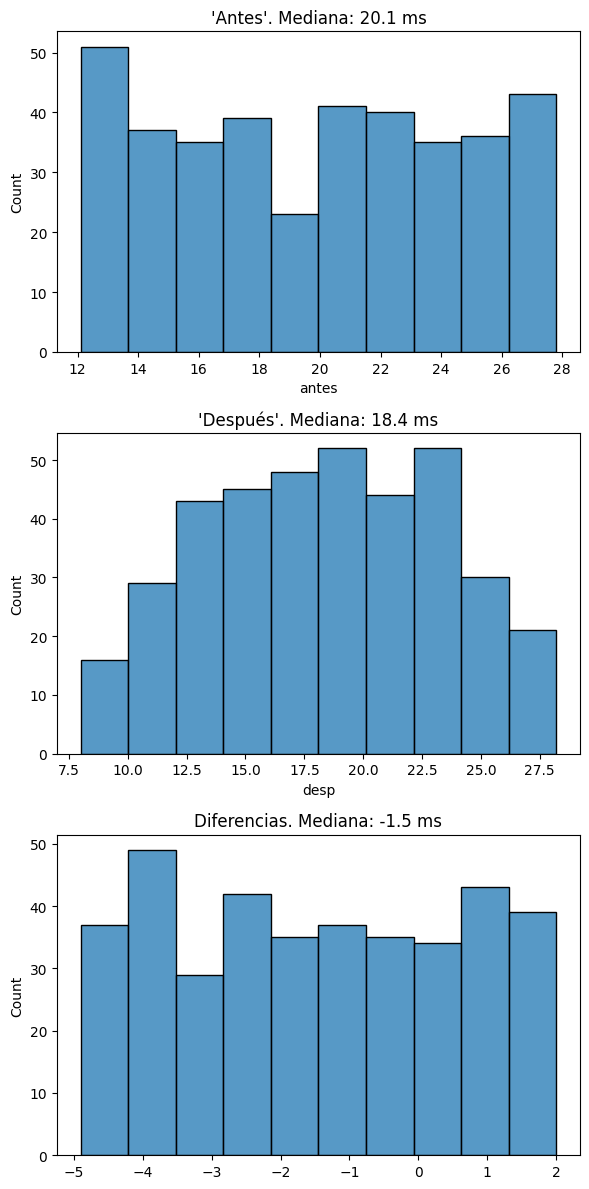

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3,1,figsize=(6,12))

# Medianas
dif = datos['desp']-datos['antes']
med_antes = datos['antes'].median()
med_desp = datos['desp'].median()
med_dif = dif.median()

# Distribución antes
sns.histplot(datos['antes'], ax=axs[0])
axs[0].set_title(f"'Antes'. Mediana: {med_antes:.1f} ms")

# Distribución después
sns.histplot(datos['desp'], ax=axs[1])
axs[1].set_title(f"'Después'. Mediana: {med_desp:.1f} ms")

# Distribución diferencias
sns.histplot(dif, ax=axs[2])
axs[2].set_title(f"Diferencias. Mediana: {med_dif:.1f} ms")

plt.tight_layout()


Vemos que:

- La mediana "antes" es menor que la mediana "después" (20.1 ms vs. 18.4 ms)
- Los datos "después" tienden a tener una distribución normal
- Pero las diferencias (lo que nos interesa en este caso) tienden a tener una distribución no-normal

Verifiquemos esto último con la prueba de Shapiro:

In [4]:
from scipy.stats import shapiro

W, p_shapiro = shapiro(dif)
p_shapiro

1.5146558098068158e-10

Y vemos que p < 0.05, con lo cual confirmamos que las diferencias no siguen una distribución normal y esto nos permite aplicar la prueba de Wilcoxon.

### 1.7. Paso 7: aplicar la prueba estadística para obtener el valor p

Al igual que con las pruebas paramétricas, podemos usar Scipy o pingouin de Python para estimar tanto la estadística como el valor p a partir de los datos.

Usemos "pingouin":

In [5]:
import pingouin as pg

pg.wilcoxon(datos['desp'] - datos['antes'], alternative="less")

,W-val,alternative,p-val,RBC,CLES
Wilcoxon,12164.0,less,7.712091e-29,-0.658569,NaN


Vemos que el argumento presentado a esta función es **la diferencia entre pares de observaciones**.

Además, es clave que indiquemos que la alternativa es "less" para intentar determinar si la mediana de las observaciones está **por debajo** del valor de referencia (las otras dos opciones son "greater" or "two-sided").

### 1.8. Paso 8: aceptar o rechazar $H_0$


Como p<0.05, esto nos indica que hay evidencia suficiente para **rechazar** la hipótesis nula (diferencias iguales a cero) y por tanto podemos decir que:

> **El tiempo de inferencia tras las modificaciones es estadísticamente menor que el de la API original**.

### 1.9. Paso 9: evaluar el tamaño del efecto y la potencia de la prueba post-hoc

Con pingouin ya encontramos el tamaño del efecto (RBC = -0.65). Esto quiere decir que:

- El signo negativo indica que efectivamente los tiempos "después" son menores que los tiempos "antes"
- La magnitud de 0.65 indica  que el tamaño del efecto es grande

Calculemos la potencia siguiendo el mismo método de la lección 2:

In [6]:
n = len(datos)
rbc = -0.6586 # <- El obtenido tras aplicar la prueba

# Convertir RBC al d de Cohen
d_obs = 2 * rbc / math.sqrt(1 - rbc**2)

# Usar power_ttest pero multiplicar n por 0.955
power = pg.power_ttest(
    d = d_obs,
    n = n * 0.955, 
    alpha = alpha, 
    contrast = 'paired', 
    alternative = 'less'
)

print(f"Potencia Post-hoc: {power:.4f}")

Potencia Post-hoc: 1.0000
